In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing

In [2]:
np.random.seed(42)
rows = 1500
data = {
    "OverallQual": np.random.randint(1, 11, rows),
    "GrLivArea": np.random.randint(500, 4500, rows),
    "GarageCars": np.random.randint(0, 5, rows),
    "GarageArea": np.random.randint(0, 1000, rows),
    "TotalBsmtSF": np.random.randint(0, 3000, rows),
    "BedroomAbvGr": np.random.randint(1, 7, rows),
    "FullBath": np.random.randint(1, 5, rows),
    "YearBuilt": np.random.randint(1950, 2024, rows),
    "LotArea": np.random.randint(1000, 20000, rows),
}
sale_price = (
    data["OverallQual"] * 30000 +
    data["GrLivArea"] * 120 +
    data["GarageCars"] * 10000 +
    data["GarageArea"] * 25 +
    data["TotalBsmtSF"] * 35 +
    data["BedroomAbvGr"] * 5000 +
    data["FullBath"] * 8000 +
    (2024 - data["YearBuilt"]) * (-300) +
    np.random.randint(-20000, 20000, rows)
)

data["SalePrice"] = sale_price
df = pd.DataFrame(data)
df.to_csv("house_price.csv", index=False)
print("Dataset created successfully!")
print("Rows:", len(df))
print(df.head())

Dataset created successfully!
Rows: 1500
   OverallQual  GrLivArea  GarageCars  GarageArea  TotalBsmtSF  BedroomAbvGr  \
0            7       1488           0         756         2248             2   
1            4        777           2         150         1580             1   
2            8       1719           3         110          961             1   
3            5       3463           2         479         2630             6   
4            7       2387           2         435          875             1   

   FullBath  YearBuilt  LotArea  SalePrice  
0         2       2006    19582     495473  
1         3       1999     3287     301047  
2         4       2020    12957     564516  
3         3       1964     5008     721494  
4         2       1967    12696     565986  


In [3]:
df.head()

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,BedroomAbvGr,FullBath,YearBuilt,LotArea,SalePrice
0,7,1488,0,756,2248,2,2,2006,19582,495473
1,4,777,2,150,1580,1,3,1999,3287,301047
2,8,1719,3,110,961,1,4,2020,12957,564516
3,5,3463,2,479,2630,6,3,1964,5008,721494
4,7,2387,2,435,875,1,2,1967,12696,565986


In [4]:
df.tail()

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,BedroomAbvGr,FullBath,YearBuilt,LotArea,SalePrice
1495,7,1706,1,135,2321,6,4,1968,8956,541596
1496,10,3028,1,791,1577,6,4,1978,13566,787242
1497,9,1669,3,782,495,6,2,2010,3526,574946
1498,2,1330,4,170,2148,6,2,2019,8803,399320
1499,5,2151,0,158,556,6,3,1973,7574,471879


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   OverallQual   1500 non-null   int32
 1   GrLivArea     1500 non-null   int32
 2   GarageCars    1500 non-null   int32
 3   GarageArea    1500 non-null   int32
 4   TotalBsmtSF   1500 non-null   int32
 5   BedroomAbvGr  1500 non-null   int32
 6   FullBath      1500 non-null   int32
 7   YearBuilt     1500 non-null   int32
 8   LotArea       1500 non-null   int32
 9   SalePrice     1500 non-null   int32
dtypes: int32(10)
memory usage: 58.7 KB


In [6]:
df.describe()

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,BedroomAbvGr,FullBath,YearBuilt,LotArea,SalePrice
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1.500000e+03
mean,5.472000,2506.812000,1.996000,510.918667,1481.008000,3.480667,2.515333,1987.192000,10731.496667,5.757232e+05
std,2.919172,1156.025431,1.421266,288.405756,849.599139,1.693381,1.109919,21.529022,5557.338171,1.689206e+05
min,1.000000,501.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1950.000000,1011.000000,1.651160e+05
25%,3.000000,1490.250000,1.000000,255.000000,739.250000,2.000000,2.000000,1968.000000,5929.000000,4.470578e+05
50%,5.000000,2520.000000,2.000000,508.500000,1481.500000,3.500000,3.000000,1987.000000,10830.500000,5.762235e+05
75%,8.000000,3506.750000,3.000000,761.250000,2198.000000,5.000000,3.000000,2006.000000,15688.500000,6.984170e+05
max,10.000000,4499.000000,4.000000,998.000000,2999.000000,6.000000,4.000000,2023.000000,19977.000000,1.036053e+06


In [7]:
df.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
BedroomAbvGr    0
FullBath        0
YearBuilt       0
LotArea         0
SalePrice       0
dtype: int64

In [8]:
print(df.columns)

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
       'BedroomAbvGr', 'FullBath', 'YearBuilt', 'LotArea', 'SalePrice'],
      dtype='object')


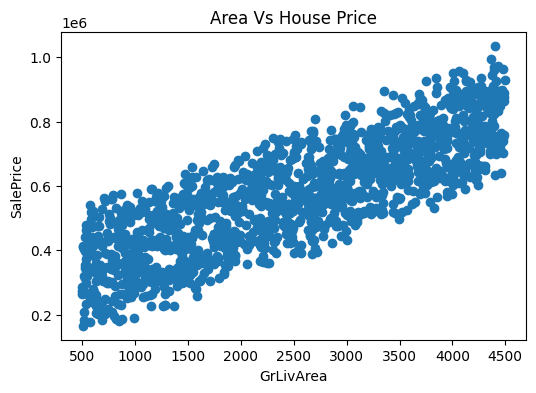

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(df['GrLivArea'],df['SalePrice'])
plt.title("Area Vs House Price")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

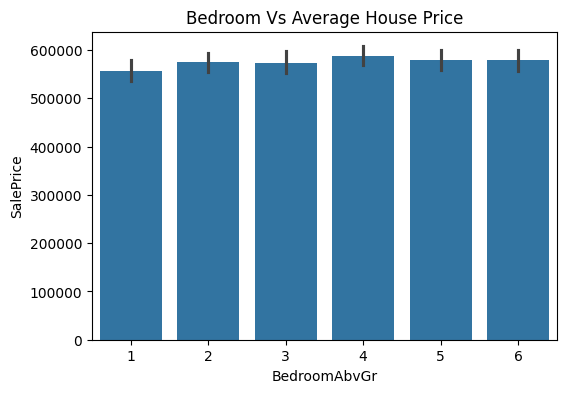

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(x='BedroomAbvGr', y='SalePrice', data=df)
plt.title("Bedroom Vs Average House Price")
plt.xlabel("BedroomAbvGr")
plt.ylabel("SalePrice")
plt.show()

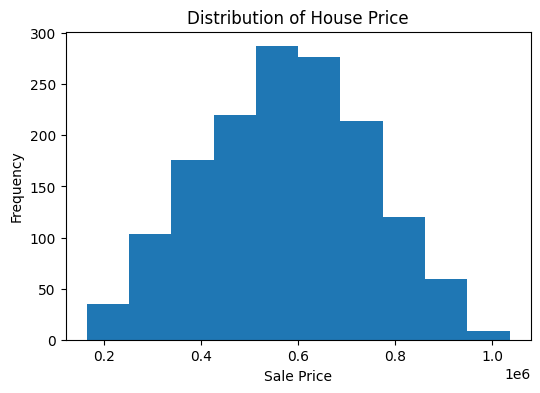

In [11]:
plt.figure(figsize=(6,4))

plt.hist(df['SalePrice'], bins=10)

plt.title("Distribution of House Price")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

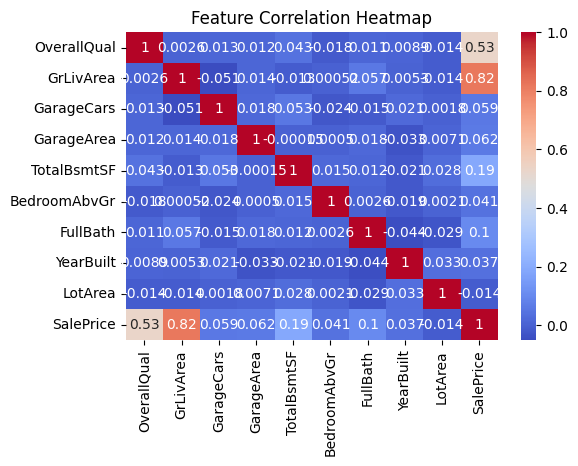

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [13]:
X = df[['BedroomAbvGr', 'FullBath', 'GrLivArea']]
y = df['SalePrice']

In [14]:
X_train, X_test, y_train, y_test=train_test_split(
     X,y, test_size=0.2, random_state= 42
)


In [15]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[563053.92473251 710696.04501168 699601.02572077 470953.19793675
 479949.02032083 360355.38022503 488438.86901664 707898.39409126
 676372.80326326 441253.13831568]


In [17]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:",mae)

MAE: 84600.21693003715


In [18]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 10046617915.097395


In [19]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 100232.81855309365


In [20]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6458447906492645


In [21]:
r2 = r2_score(y_test, y_pred)
print("Accuracy = {:.2f}%".format(r2 * 100))

Accuracy = 64.58%


In [24]:
import pickle
with open("house_price_model.pkl", "wb")as file:
    pickle.dump(model,file)
print("Model Saved Successfully!")

Model Saved Successfully!


In [25]:
with open("house_price_model.pkl","rb")as file:
    loaded_model = pickle.load(file)
    print("Model Loaded Successfully!")

Model Loaded Successfully!


In [26]:
sample = [[3,2,1500]]
prediction = loaded_model.predict(sample)
print("Prediction Price:",prediction[0])

Prediction Price: 451924.12970002816


C:\Users\inter\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
